## **3. Workflow Type 3 : Prompt Chaining Workflow**

A workflow where multiple prompts are connected, and each prompt’s output becomes the input for the next prompt.

👉 Breaks complex tasks into smaller prompt steps

👉 Improves accuracy and control

**Example:
Prompt 1 (Extract info) → Prompt 2 (Analyze) → Prompt 3 (Generate result)**

In [1]:
!pip install langchain langgraph langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 13.5 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28


In [2]:
import os

from google.colab import userdata
gem = userdata.get('gemini')

os.environ["GOOGLE_API_KEY"]=gem

## ***Step 1 : Understand the Problem Statements***

In [ ]:
# Based on that create a prompt chaining

# We are building an application (Real world story generator) where the user provides the genre and number of characters.
# Based on these inputs, the application generates a story that feels like it is created by a real-world writer.
# Genre and No of characters we give to --> Story writer --> First he/she --> Design a charater --> Plot the charters --> Story
# A detective (character) investigates a mystery → finds clues → faces challenges → solves the case --> This full sequence is the plot

## ***Step 2 : Create a state***
- Using PyDantic/TypeDict : Mostly we are using Pydantic: Create our own schema using them (Template).

- They define the structure, type, and rules of your state (shared memory) so every node in the graph works consistently and safely.

In [5]:
from pydantic import BaseModel, Field

# Create our state schema
class Data(BaseModel):
  genre:str
  no_of_char:int
  character:str|None = Field(default=None)
  plot:str|None = Field(default=None)
  story:str|None = Field(default=None)

## ***Step 3: Create a State Graph Object***

- With the help of state graph object we can able create entire state graph.
- This object will tell how to add nodws, how to add edges so the final graph will be designed

In [6]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate,HumanMessagePromptTemplate

In [7]:
# Creating our state graph object
graph = StateGraph(state_schema=Data)

## ***Step 4: Create Graph using Nodes(Steps) and Edges(connection)***

In [22]:
# design the node 1: character

def character_design(state:Data):
  cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("You are having 10 years of experience in designing the characters create a hindi charaters"),
                                          HumanMessagePromptTemplate.from_template("Based on this genre:{genre} and the no of characters: {no_of_char} design each characters correctly")])

  model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
  app = cpt | model

  answer = app.invoke({"genre":state.genre,"no_of_char":state.no_of_char})
  state.character =answer.content
  return state


In [23]:
# design the node 2: Plot

def plot_creating(state:Data):
  cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("You are having 10 years of experience in designing a plot"),
                                          HumanMessagePromptTemplate.from_template("Based on this genre:{genre} and the character design: {character} create a excellent plot ")])

  model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
  app = cpt | model

  answer = app.invoke({"genre":state.genre,"character":state.character})
  state.plot =answer.content
  return state



In [24]:
# design the node 3: Story_creation

def Story_creation(state:Data):
  cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("You are having 10 years of experience in writing a story"),
                                          HumanMessagePromptTemplate.from_template("Based on this genre:{genre} and the character design: {character} and plot: {plot} create me an short, excellent story")])

  model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
  app = cpt | model

  answer = app.invoke({"genre":state.genre,"character":state.character,"plot":state.plot})
  state.story =answer.content
  return state


In [25]:
# Add the nodes

graph.add_node("character_design",character_design)
graph.add_node("plot_creating",plot_creating)
graph.add_node("Story_creation",Story_creation)

ValueError: Node `character_design` already present.

In [26]:
# Add the edges

graph.add_edge(START,"character_design")
graph.add_edge("character_design","plot_creating")
graph.add_edge("plot_creating","Story_creation")
graph.add_edge("Story_creation",END)

In [27]:
state_graph = graph.compile()

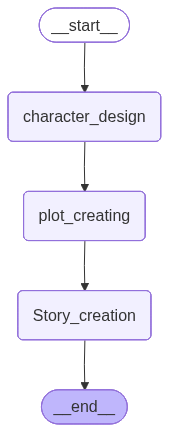

In [28]:
state_graph

In [29]:
document = state_graph.invoke({"genre":"comedy","no_of_char":5})

In [30]:
print(document["character"])

Excellent! With 10 years of experience in character design, I understand that in comedy, characters aren't just funny individuals; they're parts of a comedic engine, designed to bounce off each other, amplify absurdities, and create a dynamic ensemble.

Here are 5 distinct characters for a comedy series, designed with their visual appeal, personality, role, and comedic function in mind:

---

### **Comedy Ensemble: "The Misfit Metropolis"**

**Core Concept:** A group of disparate individuals who, through a series of unfortunate (and hilarious) events, are forced to work together in a quirky, low-stakes urban setting (e.g., running a failing community center, a bizarre local newspaper, or a highly inefficient small business).

---

### **Character 1: Ben Carter - The Perpetually Stressed Straight Man**

*   **Visual Design:**
    *   **Age:** Mid-30s.
    *   **Silhouette:** Average build, but slightly hunched shoulders, giving a perpetually burdened look. Always appears a little "crump

In [31]:
print(document["plot"])

Excellent! With these brilliantly designed characters, the "Misfit Metropolis" is practically writing itself. Your meticulous attention to visual cues, personality, role, and comedic function for each character creates a rich tapestry of potential interactions and hilarious scenarios.

Let's weave these threads into a compelling and uproarious plot for a premiere episode. We'll lean into the idea of a **failing community center** – "The Harmony Hub" – as it provides a perfect low-stakes, high-absurdity canvas for our ensemble.

---

### **The Misfit Metropolis: Episode 1 - "The Harmony Hub Hazard"**

**Logline:** When the Harmony Hub Community Center faces imminent closure, perpetually stressed manager Ben attempts to host a "Grand Re-Opening Gala" to impress a crucial donor, but his chaotic team's well-intentioned blunders turn the event into an unforgettable (and highly destructive) spectacle.

---

**Characters at Play:**

*   **Ben Carter:** The reluctant leader, desperate to save 

In [32]:
print(document["story"])

The Harmony Hub Community Center smelled faintly of forgotten dreams and damp cardboard. Ben Carter, mid-thirties and already sporting the permanent hunch of a man carrying the weight of the world (or at least, a failing community center), stared at the city council’s final notice. *One week.* One week to secure a major donation, or the Hub – his Hub, despite its eccentricities – would be shuttered. He ran a hand through his perpetually disobedient hair, his internal monologue a symphony of impending doom.

"Alright, team!" he announced, trying for a tone of authority that only came out as strained. "Emergency meeting! Tonight, we host Ms. Penelope Sterling, a major philanthropist. We need a 'Grand Re-Opening Gala' to impress her. Think elegant. Think professional."

Larry "The Loony" Lumpkin, a gangly explosion of red hair and mismatched clothes, beamed. "Elegant! Got it, Ben! I'll make a balloon animal jungle! And a confetti cannon!" He pulled a sketch from his pocket – a terrifying 